# **Lab 8 - Equazioni Differenziali Ordinarie II**

## ODE di ordine superiore al primo e sistemi di ODE

Tutto quello che abbiamo fatto per ODE scalari si generalizza facilmente al contesto vettoriale (**sistema di ODE**), dove, in sostanza, non abbiamo più una singola quantità evolvente nel tempo, ma una collezione di $d$ variabili $\mathbf{y}(t)\in\mathbb{R}^{d}$. Ciò è molto utile anche per modellizzare fenomeni scalari la cui dinamica sia descritta da equazioni di ordine superiore: ad esempio, una ODE del secondo ordine nella variabile $x$

\begin{equation*}
x''(t)=f(t,x(t),x'(t))
\end{equation*}

si può riscrivere come

\begin{equation*}
\mathbf{y}'(t)=\mathbf{f}(t,\mathbf{y}(t))
\end{equation*}

avendo posto $\mathbf{y}'(t):=[x(t),\;x'(t)]^{\top}$ il vettore di posizione e velocità, mentre $\mathbf{f}(\mathbf{y}):=[y_{2},\;f(t, y_{1}, y_{2})]^{\top}.$

## Esercizio 1

Si consideri l'equazione che descrive l'oscillatore armonico smorzato e forzato data da:

$$
\begin{cases}
m \ddot x = -kx - \gamma\dot x + f_0 \cos(\Omega t), \quad t_0<t\leq t_{\max}, \\
\dot x(t_0) = v_0, \\
x(t_0) = x_0,
\end{cases}
$$

dove $m$ è la massa dell'oggetto attaccato alla molla, $k$ la costante elastica della molla, $\gamma$ il coefficiente di smorzamento e $f_0\cos(\Omega t)$ è un termine forzante di ampiezza $f_0$ e frequenza $\Omega$.
La pulsazione dell'oscillazione è definita come

$$
\omega = \sqrt{\dfrac{k}{m}}.
$$

In [ ]:
y1=x
y2=dx/dt #y2 è la derivata prima di x, per cui la derivata seconda di x è la derivata prima di y2
#pertanto, il sistema diventa: m*(dy2/dt)=-k*y1 - gamma*y2+f0...
#y2(t0)=v0; y1(t0)=x0 condizioni iniziali

#Affronteremo due casi: o sistemi di edo oppure casi in cui ci si deve ricondurre alla forma vettoriale, per poi
#risolverli con i metodi visti la lezione precedente (eulero avanti, indietro, ...)

<mark>**Esercizio 1.1**</mark></br>

Si scriva l'equazione dell'oscillatore armonico come sistema di equazioni differenziali ordinarie del primo ordine.

In [ ]:
#vedi registrazione x appunti lavagna......

<mark>**Esercizio 1.2**</mark></br>

Si risolva il problema differenziale ottenuto con Eulero in avanti. A tale scopo, si utilizzi la funzione `eulero_avanti` contenuta in `utilis_ODE`, che è stata opportunamente modificata in modo da gestire correttamente anche il caso vettoriale. Si approssimi la soluzione per $t_0 = 0$, $t_\text{max} = 1$, $m=1$, $k=100$, $v_0=0$, $x_0=1$, $\gamma= 0$, $f_0=0$.

Si confronti graficamente la soluzione esatta $x(t) = \cos(10t)$ con quella ottenuta ponendo $h=0.1$, $h= 0.01$ e $h=0.001$. Si commentino i risultati.

In [ ]:
import numpy as np
from utilis_ODE import eulero_avanti

In [ ]:
help(eulero_avanti)
#f (callable) significa che deve essere una funzione tipo lambda function

In [ ]:
# Dati del problema
t0 = 0
t_max = 1
x0 = 1
v0 = 0
m = 1 #massa sistema oscillante/massa oscillatore
k = 100 #rigidezza sistema

# Soluzione esatta
u_ex = lambda t: np.cos(10 * t)

Poiché $f_0 = \gamma = 0$, la funzione $\mathbf{f}$ si semplifica e risulta essere

$$
\mathbf{f}(t,\mathbf{y}) =
\left[
  y_2,\;\;
  -\dfrac{k}{m}y_1
\right]^\top.
$$

In particolare, possiamo implementare $\mathbf{f}$ attraverso un'opportuna lambda function: essa dovrà ricevere in input due variabili (una scalare, $t$, ed una vettoriale $\mathbf{y}\in\mathbb{R}^{2}$), mentre dovrà restituire un vettore bi-dimensionale.

In [ ]:
f = lambda t,y: np.array([y[1], -k/m*y[0]]) #si vuole scrivere la funzione f(t,y) scritta sopra;
#in particolare, il termine di dx dell'uguale contiene y2=y[1] e y1=y[0] --> si tratta di un array di 2 componenti

In [ ]:
# Risolvo il sistema
h=0.1
t_h, u_h = eulero_avanti(f,t0,t_max,[x0, v0], h) #y0 è il vettore delle condizioni iniziali; o lo costruisco prima,
#oppure posso semplicemente mettere come input del metodo di ee il vettore stesso [x0, v0] posizione e spostamento

#facendo u_h.shape emerge che si tratta di una matrice con 2 righe (corrispondenti a y1 e y2) e 11 colonne (corrispondenti 
#ai vari istanti temporali in cui è discretizzato l'intervallo considerato)

Attenzione alla dimensione della soluzione! Ora è una matrice: le righe rappresentano le due variabili $y_1, y_2$ mentre le colonne sono gli istanti temporali.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(num=2, figsize = (6,3))

# Confronto le soluzioni numeriche al variare di h
for h in [0.1, 0.01, 0.001]:
    t_h, u_h = eulero_avanti(f,t0,t_max,[x0, v0], h)
    plt.plot(t_h, u_h[0,:], "-", alpha=0.5, label="EA (h = %.0e)" % h, linewidth=3) #devo estrarre la prima riga della matrice u_h,
    #quindi: riga 0 tutte le colonne, ossia u_h[0,:]


# Rappresento la soluzione esatta
tt = np.linspace(t0, t_max, 100)

plt.plot(tt, u_ex(tt), "--", label="Esatta")
plt.legend()
plt.show()

In [ ]:
#la soluzione numerica in corrispondenza di h=0.01, 0.001 si ottiene la soluzione sostanzialmente esatta;
#quindi anche fisicamente emerge in modo coerente il comportamento dell'oscillatore armonico, per cui risulta corretto.

<mark>**Esercizio 1.3**</mark></br>

Si discuta l'assoluta stabilità del metodo di Eulero esplicito per questo problema. Si verifichi poi il comportamento della soluzione numerica per $t_{\text{max}} = 100$ e $h=0.001$.

**Remark:** nel caso vettoriale, l'assoluta stabilità di un metodo numerico si studia con riferimento al seguente problema modello generalizzato:

$$
\begin{cases}
\mathbf{y}'(t) = J \mathbf{y}(t) \\
\mathbf{y}(t) = \mathbf{y}_0
\end{cases}
$$

dove, $J$ è una matrice data (per semplicità assumiamo che $J$ non dipenda dal tempo). Nel caso in cui $J$ ammette $n$ autovalori distinti $\lambda_i \in \mathbb{C}$, la condizione di assoluta stabilità per il metodo di Eulero esplicito risulta una generalizzazione di quella vista nel caso scalare:

$$
|1+\lambda_i h| < 1 \quad \forall i = 1,...,n
$$

In [ ]:
from scipy.linalg import eigvals #per il calcolo degli autovalori

# Definisco J (osservo che non dipende dal tempo)
J=np.array([[0, 1], 
            [-k/m, 0]]) #NB: definizione di una matrice !!!


# Calcolo gli autovalori di J
eigvals(J)

In [ ]:
#i due autovalori sono lambda1,2 = 0 +/- 10*j

In [ ]:

abs(1+eigvals(J)*h)<1 #corrisponde a: (radice quad di 1^2 + (10h)^2) < 1

In [ ]:
#la disequazione non ammette soluzione, per cui il metodo è, per questo problema, INSTABILE.

In [ ]:
# Verifico come si comporta la soluzione per tempi lunghi
t_h, u_h = eulero_avanti(f, t0, 100, [x0, v0], 0.001) #t_max=100; h=0.001

plt.plot(t_h, u_h[0, :]) #si vuole solo lo spostamento x0, per cui seleziono solo la prima riga
plt.show()

In [ ]:
#la soluzione con i tempi lunghi tende a essere sempre meno stabile, per ogni h (anche se fosse molto piccolo)

<mark>**Esercizio 1.4**</mark></br>

Si risolva il problema differenziale con il metodo di Eulero implicito. A tale scopo, si utilizzi la funzione `eulero_indietro` che è stata opportunamente modificata in modo da gestire correttamente anche il caso vettoriale, sotto l'ipotesi che $\mathbf{f}$ sia rappresentabile attraverso una matrice, come $\mathbf{f} = A \mathbf{y}$ (ovvero, consideriamo solo il caso di **ODE lineari**, mentre non vediamo a laboratorio il caso di ODE non lineari, per il quale però `eulero_indietro` si potrebbe tranquillamente generalizzare).

Si approssimi la soluzione per $t_0 = 0$, $t_\text{max} = 1$, $m=1$, $k=100$, $v_0=0$, $x_0=1$, $\gamma= 0$, $f_0=0$. Si confronti graficamente la soluzione esatta $x(t) = \cos(10t)$ con quella ottenuta ponendo $h=0.001$, $h= 0.01$ e $h=0.1$. Si commentino i risultati.

In [ ]:
from utilis_ODE import eulero_indietro

help(eulero_indietro)

In [ ]:
# Dati del problema
t0 = 0
t_max = 1
x0 = 1
v0 = 0
m = 1
k = 100
gamma = 0

# Soluzione esatta
u_ex = lambda t: np.cos(10 * t)

# Risolvo il sistema al variare di h
for h in [0.1, 0.01, 0.001]:
    t_h, u_h = eulero_indietro(J, t0, t_max, [x0,v0], h) #siamo nel caso vettoriale e lineare, per cui il metodo di 
    #eulero implicito vuole come input la matrice J definita prima, non f definita come lambda function.
    plt.plot(t_h, u_h[0,:], "-o", alpha=0.5, label="EI (h = %.0e)" % h)

tt = np.linspace(t0, t_max, 100)
plt.plot(tt, u_ex(tt), label="Esatta")

plt.legend()
plt.show()

In [ ]:
#al ridursi di h la soluzione numerica converge e si ha la soluzione esatta, ed emerge l'andamento oscillante dell'oscillatore armonico.

#verifico come si comporta la soluzione per tempi lunghi
t_h, u_h = eulero_indietro(J, t0, 100, [x0, v0], 0.001) #t_max=100; h=0.001

plt.plot(t_h, u_h[0, :]) #si vuole solo lo spostamento x0, per cui seleziono solo la prima riga
plt.show()

In [ ]:
#il metodo numerico introduce una DISSIPAZIONE ARTIFICIALE, uno smorzamento che, fisicamente, non c'è.
#Si tratta di un metodo STABILE, in quanto all'avanzare del tempo l'ampiezza delle oscillazioni diminuisce.

## Metodi di alto ordine per ODE

I metodi numerici utilizzati per risolvere il generico problema di Cauchy:

$$
\begin{cases}
y'(t) = f(t,y), \quad t_0<t\leq t_{\max}, \\
y(t_0) = y_0,
\end{cases}
$$

si basano sulla seguente strategia:

1. Stabilire un passo di avanzamento temporale $h$,

2. Suddividere l'intervallo temporale $[t_0,t_{\max}]$ in un numero $N_h$ di sottointervalli
$$ N_h = \frac{t_{\max}-t_0}{h} $$
di eguale ampiezza $h$,

3. Per ogni istante temporale discreto $t_n$, con $t_0 < t_n < t_{\max}$, si calcola il valore incognito $u_n$ che approssima la soluzione $y_n=y(t_n)$.

L'insieme dei valori $\{u_0 = y_0, \ u_1,\dots,u_{N_h}\}$ rappresenta la soluzione numerica del problema di Cauchy.

Nel Lab 7 sono stati introdotti i metodi di *Eulero avanti*, *Eulero indietro* e *Crank-Nicolson*. In questo Laboratorio vogliamo però indagare metodi che garantiscano un ordine di convergenza superiore. Esistono due famiglie di metodi a tal proposito:

*   **Metodi di Runge-Kutta**, che per calcolare $u_{n+1}$ sfruttano più stadi costruendo la soluzione in modo nonlineare.
*   **Metodi multistep**, che per calcolare $u_{n+1}$ sfruttano non solo $u_n$, ma anche la soluzione numerica calcolata in istanti precedenti.

In particolare, ci occupiamo della prima famiglia.

## Metodi di Runge-Kutta (RK)

I metodi di Runge-Kutta sono dei metodi **a un passo**, ma rispetto a Eulero in avanti consentono di raggiungere un ordine di accuratezza più elevato. Ad ogni passo, la soluzione numerica è calcolata secondo la seguente formula:

$$
u_{n+1} = u_{n} + h F(t_n, u_n, h; f)
$$

Ad esempio, il metodo di Runge-Kutta esplicito a due stadi, anche noto come **metodo di Heun**, risulta:

$$
\begin{cases}
u_* = u_{n} + h f(t_n, u_n) \\
u_{n+1} = u_{n} + \frac{h}{2} \left(f(t_n, u_n) + f(t_{n+1}, u_*) \right)
\end{cases}
$$

Oppure, in generale, un metodo di Runge-Kutta a *s* stadi può essere scritto come:

$$
F(t_n, u_n, h; f) = \sum_{i=1}^s b_i K_i
$$

$$
K_i = f \left(t_n + c_i h ~,~ u_n + \sum_{j=1}^s a_{ij} K_j \right)  \quad\quad i = 1,...,s
$$

## Esercizio 2

Si consideri il problema di Cauchy

$$
\begin{cases}
y'(t) = -ty(t), \quad t_0<t\leq t_{\max}, \\
y(t_0) = 1,
\end{cases}
$$

con $t_0 = 0$ e $t_\text{max} = 5$, la cui soluzione esatta è data da: $y(t) = e^{- \frac{t^2}{2} }$

<mark>**Esercizio 2.1**</mark></br>

Si risolva il problema di Cauchy con il metodo di Eulero in avanti, sfruttando lo script `utilis_ODE.py`, con passo $h=0.01$ e si calcoli l'errore assoluto

$$
e_h = \max_{n=1,\dots,N_h} |y(t_n)-u_n|.
$$

In [ ]:
import numpy as np
from utilis_ODE import eulero_avanti

# Dati del problema
f = lambda t,y: -t*y #siamo tornati al caso scalare
t0=0
t_max=5
y0=1
y_ex=lambda t: np.exp(-t**2/2)

# Risolvo il problema di Cauchy

t_EA, y_EA= eulero_avanti(f, t0, t_max, y0, h=0.01)



In [ ]:
# Calcolo l'errore
err_EA=np.max(np.abs(y_EA-y_ex(t_EA)))
nstepsEA=len(t_EA)-1 #il numero di passi del metodo di eulero avanti è pari alla lunghezza del vettore t_EA (-1 per togliere l'istante iniziale)

print("Errore globale EA:\t%.2e" % err_EA)
print("Passi effettuati:\t%d" % nstepsEA)

<mark>**Esercizio 2.2**</mark></br>

Si risolva ora il problema con il metodo di Runge-Kutta a 3 stadi (s=3). Ad esempio, una delle possibili formulazioni è la seguente:

$$
\begin{cases}
u_0 = y_0 \\
u_{n+1} = u_n + \frac{h}{6} (K_1 + 4 K_2 + K_3) \quad\quad n=0,...,N_h
\end{cases}
$$

dove,
$$
\begin{aligned}
K_1 & = f(t_n, u_n) \\
K_2 & = f(t_n + \frac{1}{2} h , u_n + \frac{1}{2} h K_1) \\
K_3 & = f(t_n + h, u_n - hK_1 + 2hK_2)
\end{aligned}
$$

A tal proposito, si sfrutti la function `RK23` della libreria Python `scipy.integrate` (fissando tolleranza relativa ed assoluta a $10^{-8}$ in `RK23`).
Si calcoli poi l'errore assoluto.

In [1]:
from scipy.integrate import RK23

*NB: RK23 implementa una variante del metodo di Runge-Kutta descritto sopra. Nello specifico, RK23 consiste in un metodo adattivo basato su due metodi di Runge-Kutta: uno di ordine 3 (per effettuare il passo) ed uno di ordine 2 (per scegliere, ad ogni step, il nuovo passo temporale $h^n$). Inoltre, diversamente dalle implementazioni che abbiamo visto finora, questa function non simula direttamente tutta la traiettoria. RK23 è una classe! Chiamando RK23 ci viene restituito un oggetto che può essere evoluto in tempo chiamando il metodo `.step()`. In sostanza, RK23 implementa l'iteratore dello schema numerico.*

*In ogni momento potete accedere agli attributi `.t`
 e `.y` dell'iteratore per conoscere, rispettivamente, il tempo corrente $t^n$ e lo stato corrente del sistema, $y^n$.*

**Approfondimento**: per chi volesse approfondire il concetto di *classe* può trovare su internet numerosi riferimenti. Qui è presente una breve spiegazione: https://aulab.it/guide-avanzate/classi-e-oggetti-in-python

In [ ]:
# Costruisco un oggetto della classe RK23=la prima cifra è l'ordine/numero di adattività, 
# pari a numero di stadi-1, mentre il secondo numero è il numero di stadi
rk23=RK23(f, t0, [y0], t_max) #la condizione iniziale, anche se è uno scalare, deve essere messo come vettore
#t bound è l'idtsnte di tempo ultimo, massimo, ossia t_max

#Quanto restituisce la funzione RK23 è una CLASSE, contenente attributi(proprietà o variabili, come il tempo t e la soluzione
# y, nel caso di RK23) e metodi (funzioni da chiamare -> a noi interessa, in questo caso, la funzione step())

#rk23 è detto iteratore ed è un oggetto della classe

# Esempio: chiamo gli attributi t e y della classe
rk23.t
rk23.y



In [ ]:
t_RK=[t0]
y_RK=[[y0]] #è un array
# Risolvo
while rk23.t < t_max:
    rk23.step()
    t_RK.append(rk23.t)
    y_RK.append(rk23.y)

t_RK=np.array(t_RK) #per poi poter plottare come array
y_RK=np.stack(y_RK)


In [ ]:
y_RK.shape

In [ ]:
# Calcolo l'errore
err_RK23=np.max(np.abs(y_RK-y_ex(t_RK)))
nstepsRK23=len(t_RK)

print("Errore globale RK23:\t%.2e" % err_RK23)
print("Passi effettuati:\t%d" % nstepsRK23)

<mark>**Esercizio 2.3**</mark></br>

Si confrontino il metodo EA con RK23, analizzando l'errore commesso nei due casi e il numero di istanti temporali utilizzati.

In [ ]:
print("Errore globale EA:\t%.2e" % err_EA)
print("Passi effettuati:\t%d" % nstepsEA)

print("Errore globale RK23:\t%.2e" % err_RK23)
print("Passi effettuati:\t%d" % nstepsRK23)

<mark>**Esercizio 2.4**</mark></br>

Si ripeta l'Esercizio 2.2 utilizzando un metodo di Runge-Kutta di ordine superiore, implementato nella function `RK45`,
 della libreria Python `scipy.integrate` e si calcoli l'errore assoluto. Cosa si può concludere?


In [6]:
from scipy.integrate import RK45

# TO DO...

print("Errore globale RK45:\t%.2e" % err_RK45)
print("Passi effettuati:\t%d" % nstepsRK45)

NameError: name 'err_RK45' is not defined

<mark>**Esercizio 2.5**</mark></br>

Confrontate graficamente soluzione esatta e approssimazioni numeriche (utilizzate quelle ottenute ai punti 2.1, 2.2 ed 2.4).



In [ ]:
import matplotlib.pyplot as plt

t_plot = np.linspace(t0, t_max, 1000)
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(t_EA, y_EA, "o", label="EA")
plt.plot(t_plot, y_ex(t_plot), label="Soluzione esatta")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t_RK23, y_RK23[:, 0], "o", label="RK23")
plt.plot(t_plot, y_ex(t_plot), label="Soluzione esatta")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(t_RK45, y_RK45[:, 0], "o", label="RK45")
plt.plot(t_plot, y_ex(t_plot), label="Soluzione esatta")
plt.legend()

plt.show()

**Remark**: qui abbiamo sfruttato l'implementazione di `scipy.integrate.RK`, che consentiva l'adattività, però attenzione a non confondere i metodi di Runge-Kutta con l'adattività. Sono due aspetti separati!

## Esercizi per casa

Si consideri nuovamente il problema dell'Esercizio 1, che descrive un oscillatore armonico smorzato e forzato:

$$
\begin{cases}
m \ddot x = -kx - \gamma\dot x + f_0 \cos(\Omega t), \quad t_0<t\leq t_{\max}, \\
\dot x(t_0) = v_0, \\
x(t_0) = x_0,
\end{cases}
$$

dove $m$ è la massa dell'oggetto attaccato alla molla, $k$ la costante elastica della molla, $\gamma$ il coefficiente di smorzamento e $f_0\cos(\Omega t)$ è un termine forzante di ampiezza $f_0$ e frequenza $\Omega$.
La pulsazione dell'oscillazione è definita come

$$
\omega = \sqrt{\dfrac{k}{m}}.
$$

<mark>**Esercizio 3.1**</mark></br>

Si ponga $t_0 = 0$, $t_{\max} = 10$, $m=1$, $k=4$, $v_0=1$, $x_0=0$.

Mediante la funzione RK45 di Python si sperimentino i seguenti casi, visualizzandone la soluzione numerica e discutendo i risultati ottenuti alla luce dei risultati teorici.

1. **Oscillatore armonico semplice**: $\gamma = f_0 = 0$.
La soluzione esatta è

$$
x(t) = A\cos(\omega t+\theta_0),
$$
dove
$$
A = -\dfrac{v_0}{\sin(\theta_0)\omega}, \quad \theta_0 = \arctan\left( \dfrac{v_0}{\omega x_0} \right).
$$</br>

2. **Oscillatore armonico sovra-smorzato**: $f_0 = 0$, $\gamma^2 >4mk$. Si assuma $\gamma=5$.
La soluzione esatta è

$$
x(t) = c_0 e^{\lambda_0 t} + c_1 e^{\lambda_1 t},
$$
dove
$$
\lambda_{k}=\frac{-\gamma+(-1)^{k}\sqrt{\gamma^{2}-4mk}}{2m},\quad\quad c_{0}=x_{0}-c_{1},\quad\quad c_{1}=\frac{v_{0}-x_{0}\lambda_{0}}{\lambda_{1}-\lambda_{0}}
$$

3. **Oscillatore armonico sotto-smorzato**: $f_0 = 0$, $\gamma^2 < 4mk$. Si assuma $\gamma = 1$.
La soluzione esatta è
$$
x(t) = e^{-\frac{\gamma}{2m}t}\left(A\cos(\omega_1 t)+B\sin(\omega_1 t)\right),
$$</br>
dove
$$
\omega_1 = \dfrac{\sqrt{4mk-\gamma}}{2m}, \quad A=x_0, \quad B=\dfrac{v_0}{\omega_1} + \dfrac{\gamma x_0}{2m\omega_1}.
$$

4. **Oscillatore armonico forzato**: $\gamma=1$, $f_0=1$, $\Omega=0.5$. In questo caso si ponga $t_{\max}=30$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import RK45

def RungeKutta45(f, t0, y0, t_max, rtol, atol):
    integratore = RK45(f, t0, y0, t_max, rtol=rtol, atol=atol)
    t_h=[t0]
    u_h=[y0]

    while integratore.t<t_max:
        integratore.step()
        t_h.append(integratore.t)
        u_h.append(integratore.y)

    return np.array(t_h), np.stack(u_h)


#è anche utile costruire una function che, dati i parametri del problema, restituisca la lambda
#function descrivente il termine di dx dell'equazione (così da non doverla definire tutte i 4 casi)

def get_f(k, m, gamma, d0, Omega):
    f=lambda t, y: [y[1], -k/m*y[0]-gamma/m*y[1]+f0/m*np.cos(Omega*t)]
    return f

#dati comuni a tutti i problemi
t0, t_max = 0, 10
x0, v0 = 0, 1
m=1
k=4
Omega=0

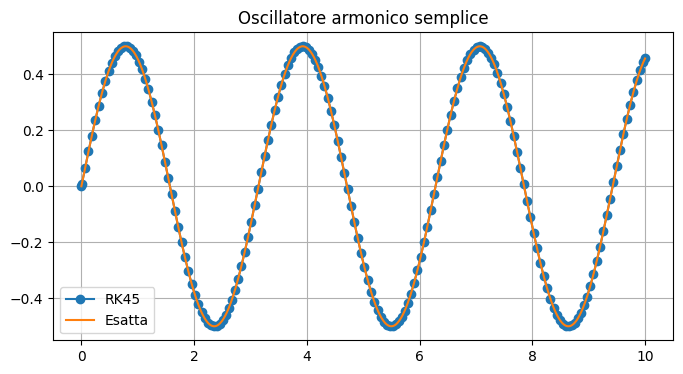

In [9]:
#Caso 1: oscillatore armonico semplice
#dati del problema
gamma=0
omega=np.sqrt(k/m)
f0=0
#soluzione esatta (arctan(v0/(omega*x0)), ma qui x0 è 0 -> pi/2)
theta0=np.pi/2.0
yex=lambda t: -v0/(omega*np.sin(theta0))*np.cos(omega*t+theta0)
#RHS del sistema
f=get_f(k, m, gamma, f0, Omega)
t_h, u_h=RungeKutta45(f, t0, [x0, v0], t_max, 1e-8, 1e-8)
plt.figure(figsize=(8, 4))
plt.plot(t_h, u_h[:, 0], "o-", label="RK45")
tt=np.linspace(t0, t_max, 1000)
plt.plot(tt, yex(tt), label="Esatta")
plt.grid()
plt.legend()
plt.title("Oscillatore armonico semplice")
plt.show()
# Salviamo la soluzione per esercizio extra
soluzione = dict()
soluzione["semplice"] = u_h


In [11]:
import spring
spring.animate(t_h, u_h[:, 0])

ModuleNotFoundError: No module named 'spring'

In [ ]:
#per altri casi vedi pdf soluzioni

<mark>**Esercizio 3.2**</mark></br>

Confrontare le soluzioni numeriche ottenute nell'Esercizio 3.1, rappresentandole nel piano delle fasi, cioè nel piano posizione-velocità, $(x,\dot{x})$.

**Extra**: tramite lo script `spring.py` è possibile visualizzare delle animazioni che mostrano visivamente il comportamento dell'oscillatore nei quattro casi considerati!